In [1]:
from glob import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re 

In [2]:
!ls -al binaural_eval/

total 0
drwxrwxr-x 2 imgriff mcdermott 4096 Aug 11 11:30 .
drwxr-xr-x 2 imgriff mcdermott 4096 Aug 11 15:35 ..
drwxrwxr-x 2 imgriff mcdermott 4096 Jul 17 20:48 word_task_voice_loc_cue
drwxrwxr-x 2 imgriff mcdermott 4096 Aug 11 02:01 word_task_voice_loc_cue_-9dB
drwxrwxr-x 2 imgriff mcdermott 4096 Aug 11 04:20 word_task_voice_loc_cue_0dB
drwxrwxr-x 2 imgriff mcdermott 4096 Aug 11 13:37 word_task_voice_loc_cue_9dB


In [3]:
!ls binaural_eval/

word_task_voice_loc_cue       word_task_voice_loc_cue_0dB
word_task_voice_loc_cue_-9dB  word_task_voice_loc_cue_9dB


In [4]:
# test_files = glob('binaural_eval/word_task_voice_and_loc_cue_8_01/*.pkl')
test_files = glob('binaural_eval/word_task_voice_loc_cue*dB/*.pkl')


In [5]:
result_df = pd.DataFrame()
condition = []
target_loc = []
distractor_loc = []
accuracy = []
acc_error = []
confusions = []
con_error = []
snr = []
for f in test_files:
    file_dict = pd.read_pickle(f)
    for con in file_dict.keys():
        condition.append(con)
        targ_loc = file_dict[con]['target_loc']
        if targ_loc[0] > 90:
            azim = 360 - targ_loc[0]
        else:
            azim = 0 - targ_loc[0]
        target_loc.append((azim, 0))
        dist_loc = file_dict[con]['distract_loc']
        if dist_loc[0] > 90:
            azim = 360 - dist_loc[0]
        else:
            azim = 0 - dist_loc[0]
        distractor_loc.append((azim, 0))
        accuracy.append(file_dict[con]['results'][0])
        acc_error.append(file_dict[con]['results'][1])
        confusions.append(file_dict[con]['confusions'][0])
        con_error.append(file_dict[con]['confusions'][1])
        snr.append(int(re.search('(-?\d+)dB', f).group(1)))
        

result_df['condition'] = condition

target_azimuth, target_elev = zip(*target_loc)
distractor_azimuth, distractor_elev = zip(*distractor_loc)

result_df['target_azimuth'] = target_azimuth
result_df['target_elevation'] = target_elev

result_df['distractor_azimuth'] = distractor_azimuth
result_df['distractor_elevation'] = distractor_elev


result_df['accuracy'] = accuracy
result_df['acc_error'] = acc_error
result_df['confusions'] = confusions
result_df['con_error'] = con_error
result_df['snr'] = snr

In [6]:
result_df

,condition,target_azimuth,target_elevation,distractor_azimuth,distractor_elevation,accuracy,acc_error,confusions,con_error,snr
0,m_m,0,0,0,0,0.035488,0.006591,0.387833,0.017358,-9
1,m_f,0,0,0,0,0.039290,0.006921,0.353612,0.017031,-9
2,f_m,0,0,0,0,0.031686,0.006240,0.344740,0.016931,-9
3,f_f,0,0,0,0,0.030418,0.006118,0.429658,0.017635,-9
4,m_m,0,0,-10,0,0.039290,0.006921,0.343473,0.016916,-9
...,...,...,...,...,...,...,...,...,...,...
4327,f_f,-90,0,-80,0,0.520913,0.017796,0.007605,0.003095,9
4328,m_m,-90,0,-90,0,0.538657,0.017758,0.008872,0.003341,9
4329,m_f,-90,0,-90,0,0.558935,0.017688,0.008872,0.003341,9
4330,f_m,-90,0,-90,0,0.551331,0.017718,0.006337,0.002827,9


<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

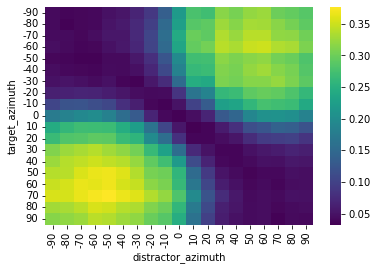

In [7]:
mean_acc = result_df[result_df.snr==-9].groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']

sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

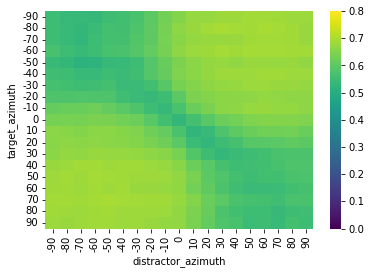

In [12]:
mean_acc = result_df[result_df.snr==9].groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']

sns.heatmap(mean_acc.unstack(), vmin=0, vmax=0.8, cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

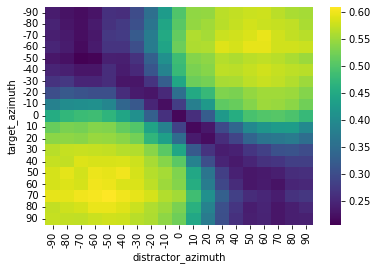

In [8]:
mean_acc = result_df[result_df.snr==0].groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']

sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

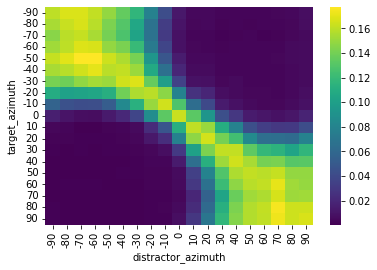

In [13]:
mean_con = result_df.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

In [46]:
same_sex = result_df[(result_df['condition'] == 'm_m') | (result_df['condition'] == 'f_f')]
print(same_sex['accuracy'].max())

0.4955640050697085


<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

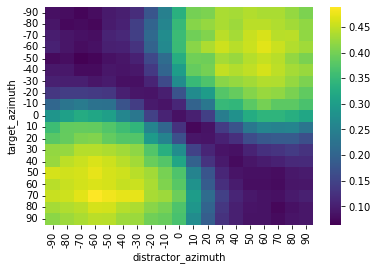

In [47]:
mean_acc = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

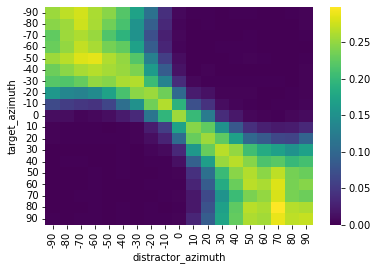

In [48]:
mean_con = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

In [49]:
diff_sex = result_df[(result_df['condition'] == 'm_f') | (result_df['condition'] == 'f_m')]
print(diff_sex['accuracy'].max())

0.5082382762991128


<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

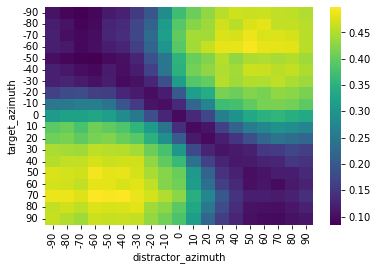

In [50]:
mean_acc = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(mean_acc.unstack(), cmap='viridis')

<AxesSubplot:xlabel='distractor_azimuth', ylabel='target_azimuth'>

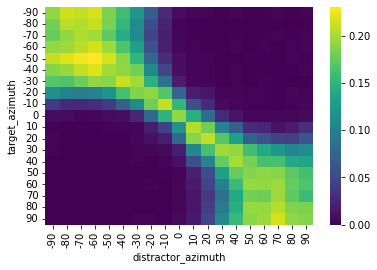

In [51]:
mean_con = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(mean_con.unstack(), cmap='viridis')

# Results by SNR 

,condition,target_azimuth,target_elevation,distractor_azimuth,distractor_elevation,accuracy,acc_error,confusions,con_error,snr
0,m_m,0,0,0,0,0.035488,0.006591,0.387833,0.017358,-9
1,m_f,0,0,0,0,0.039290,0.006921,0.353612,0.017031,-9
2,f_m,0,0,0,0,0.031686,0.006240,0.344740,0.016931,-9
3,f_f,0,0,0,0,0.030418,0.006118,0.429658,0.017635,-9
4,m_m,0,0,-10,0,0.039290,0.006921,0.343473,0.016916,-9
...,...,...,...,...,...,...,...,...,...,...
4327,f_f,-90,0,-80,0,0.520913,0.017796,0.007605,0.003095,9
4328,m_m,-90,0,-90,0,0.538657,0.017758,0.008872,0.003341,9
4329,m_f,-90,0,-90,0,0.558935,0.017688,0.008872,0.003341,9
4330,f_m,-90,0,-90,0,0.551331,0.017718,0.006337,0.002827,9


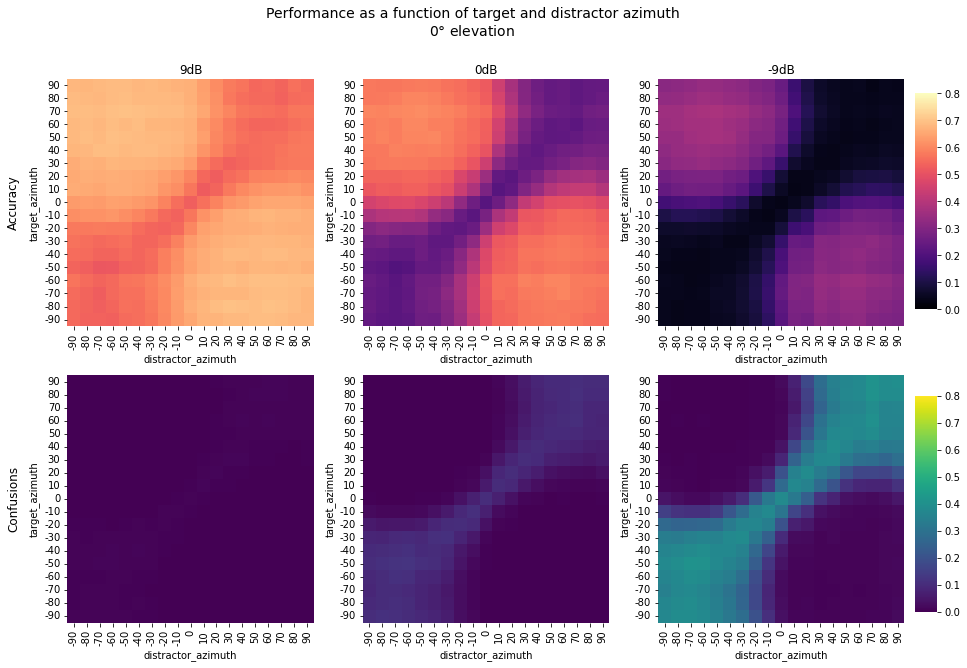

In [18]:
# plot all plots so far onto one figure
cols = ["9dB", '0dB', '-9dB']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

zero_db = result_df[result_df['snr'] == 0]
min_9_db = result_df[result_df['snr'] == -9]
plus_9_db = result_df[result_df['snr'] == 9]

plus_9_db_acc = plus_9_db.groupby(["target_azimuth", "distractor_azimuth"]).mean()['accuracy']
sns.heatmap(plus_9_db_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
plus_9db_conf = plus_9_db.groupby(["target_azimuth", "distractor_azimuth"]).mean()['confusions']
sns.heatmap(plus_9db_conf.unstack(), vmin=0, vmax=0.8, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

acc_0db = zero_db.groupby(["target_azimuth", "distractor_azimuth"]).mean()['accuracy']
sns.heatmap(acc_0db.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 1])
con_0db = zero_db.groupby(["target_azimuth", "distractor_azimuth"]).mean()['confusions']
sns.heatmap(con_0db.unstack(), vmin=0, vmax=0.8, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 1])

min_9_db_acc = min_9_db.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(min_9_db_acc.unstack(), vmin=0, vmax= .8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
min_9_db_con = min_9_db.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(min_9_db_con.unstack(), vmin=0, vmax=0.8, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

for ax in axs.flatten():
    ax.invert_yaxis()
    
# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

# np.vectorize(lambda ax: ax.invert_yaxis())(axs);

# Results by target/distractor sex

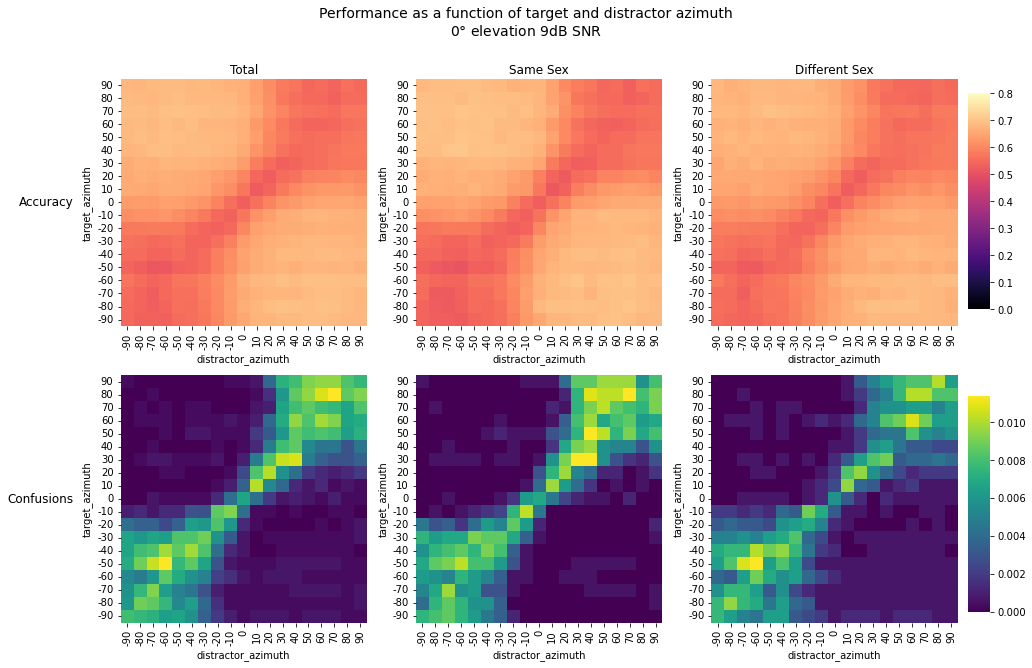

In [20]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# cbar_ax_1 = fig.add_axes([.91, .53, .03, .4])
# cbar_ax_2 = fig.add_axes([.91, .1, .03, .4])

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

same_sex = plus_9_db[(plus_9_db['condition'] == 'm_m') | (plus_9_db['condition'] == 'f_f')]
diff_sex = plus_9_db[(plus_9_db['condition'] == 'm_f') | (plus_9_db['condition'] == 'f_m')]

total_acc = plus_9_db.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = plus_9_db.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex_acc = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(same_sex_con.unstack(), vmin=0,  cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex_acc = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(diff_sex_con.unstack(), vmin=0, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])

# np.vectorize(lambda ax: ax.invert_yaxis())(axs.flatten())
for ax in axs.flatten():
    ax.invert_yaxis()

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points')
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center')
# fig.tight_layout(rect=[0,0,.9,1])

plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation 9dB SNR', fontsize=14, y=0.98);



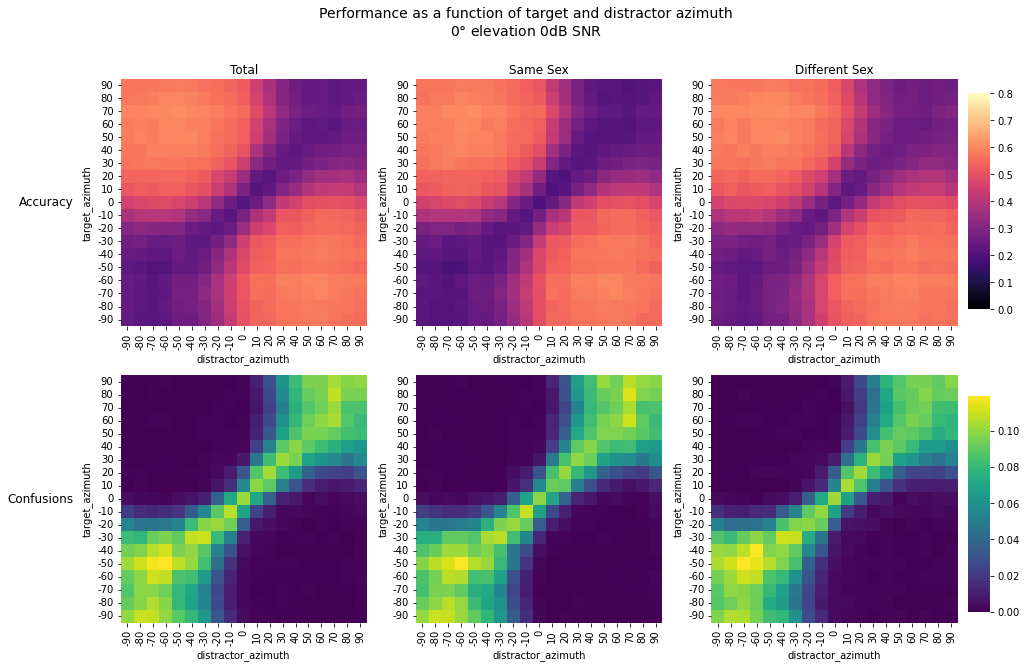

In [49]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# cbar_ax_1 = fig.add_axes([.91, .53, .03, .4])
# cbar_ax_2 = fig.add_axes([.91, .1, .03, .4])

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

same_sex = zero_db[(zero_db['condition'] == 'm_m') | (zero_db['condition'] == 'f_f')]
diff_sex = zero_db[(zero_db['condition'] == 'm_f') | (zero_db['condition'] == 'f_m')]

total_acc = zero_db.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = zero_db.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex_acc = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(same_sex_con.unstack(), vmin=0,  cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex_acc = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(diff_sex_con.unstack(), vmin=0, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])

# np.vectorize(lambda ax: ax.invert_yaxis())(axs.flatten())
for ax in axs.flatten():
    ax.invert_yaxis()

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points')
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center')
# fig.tight_layout(rect=[0,0,.9,1])

plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation 0dB SNR', fontsize=14, y=0.98);



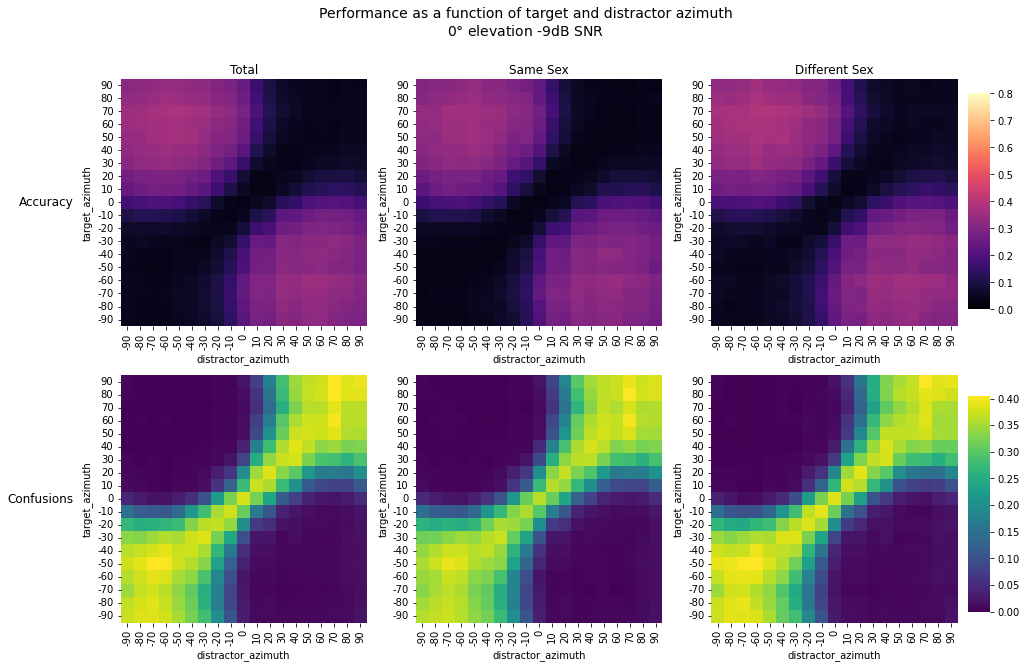

In [48]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# cbar_ax_1 = fig.add_axes([.91, .53, .03, .4])
# cbar_ax_2 = fig.add_axes([.91, .1, .03, .4])

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

same_sex = min_9_db[(min_9_db['condition'] == 'm_m') | (min_9_db['condition'] == 'f_f')]
diff_sex = min_9_db[(min_9_db['condition'] == 'm_f') | (min_9_db['condition'] == 'f_m')]

total_acc = min_9_db.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = min_9_db.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0,   cmap='viridis', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex_acc = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(same_sex_con.unstack(), vmin=0, cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex_acc = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['accuracy']
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.8, cmap='magma', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(['target_azimuth', 'distractor_azimuth']).mean()['confusions']
sns.heatmap(diff_sex_con.unstack(), vmin=0,   cmap='viridis', cbar=False, cbar_ax=None, ax=axs[1, 2])

# np.vectorize(lambda ax: ax.invert_yaxis())(axs.flatten())
for ax in axs.flatten():
    ax.invert_yaxis()

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points')
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center')
# fig.tight_layout(rect=[0,0,.9,1])

plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation -9dB SNR', fontsize=14, y=0.98);



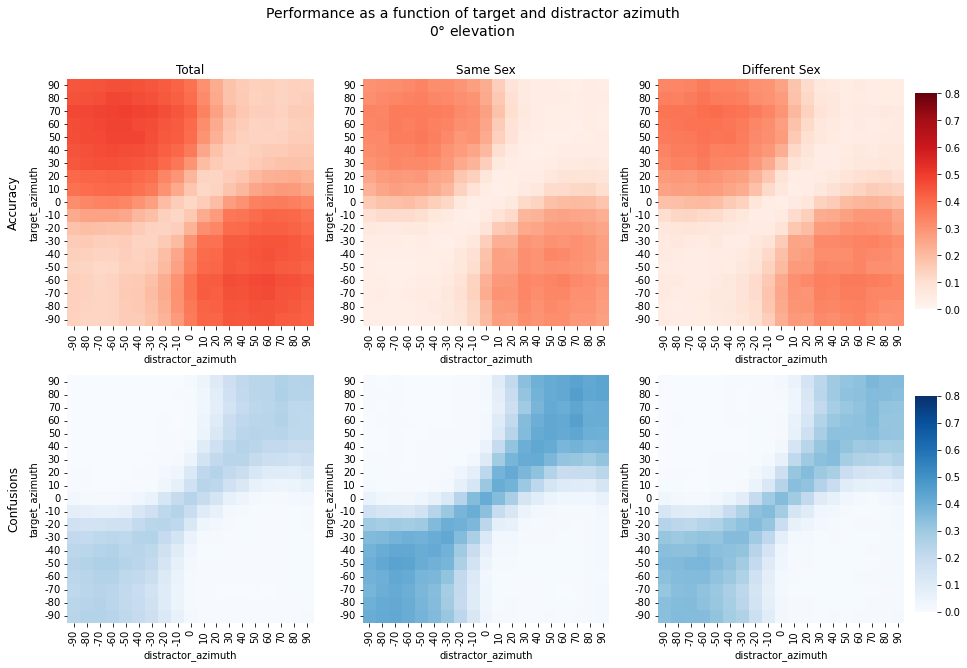

In [38]:
# plot all plots so far onto one figure
cols = ['Total', 'Same Sex', 'Different Sex']
rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

total_acc = result_df.groupby(["target_azimuth", "distractor_azimuth"]).mean()['accuracy']
sns.heatmap(total_acc.unstack(), vmin=0, vmax=.8, cmap='Reds', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0, 0])
total_con = result_df.groupby(["target_azimuth", "distractor_azimuth"]).mean()['confusions']
sns.heatmap(total_con.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1, 0])

same_sex_acc = same_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(same_sex_acc.unstack(), vmin=0, vmax= .8, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 1])
same_sex_con = same_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(same_sex_con.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 1])

diff_sex_acc = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(diff_sex_acc.unstack(), vmin=0, vmax=.8, cmap='Reds', cbar=False, cbar_ax=None, ax=axs[0, 2])
diff_sex_con = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(diff_sex_con.unstack(), vmin=0, vmax=0.8, cmap='Blues', cbar=False, cbar_ax=None, ax=axs[1, 2])

for ax, col in zip(axs[0], cols):
    ax.annotate(col, xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
for ax, row in zip(axs[:, 0], rows):
    ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

for ax in axs.flatten():
    ax.invert_yaxis()
    
# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation', fontsize=14, y=0.98);

# np.vectorize(lambda ax: ax.invert_yaxis())(axs);

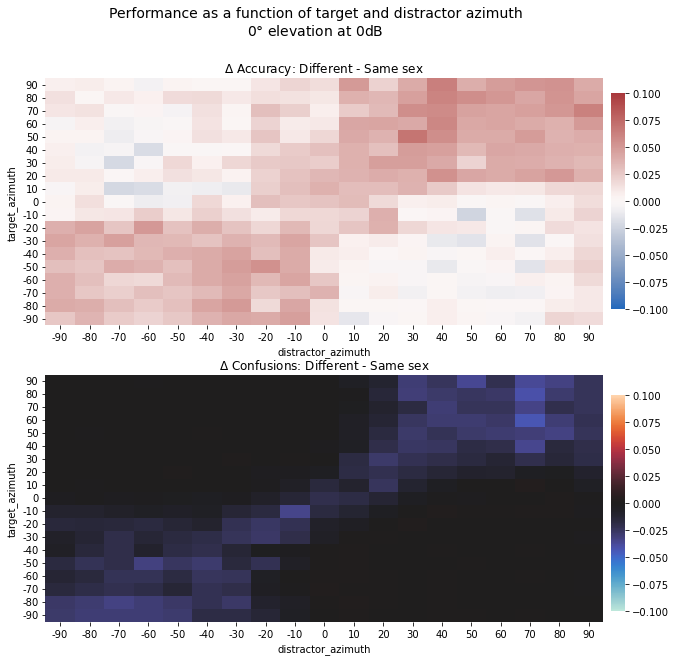

In [45]:
# plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=False, sharey=True)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

same_sex = zero_db[(zero_db['condition'] == 'm_m') | (zero_db['condition'] == 'f_f')]
diff_sex = zero_db[(zero_db['condition'] == 'm_f') | (zero_db['condition'] == 'f_m')]

diff = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean() - same_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(diff.unstack(), vmin=-0.1, vmax=0.1, cmap='vlag', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0])
diff = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean() - same_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(diff.unstack(), vmin=-0.1, vmax=0.1, cmap='icefire', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1])

# for ax, col in zip(axs[0], cols):
axs[0].set_title("$\Delta$ Accuracy: Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("$\Delta$ Confusions: Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation at 0dB', fontsize=14, y=0.98);

np.vectorize(lambda ax: ax.invert_yaxis())(axs);

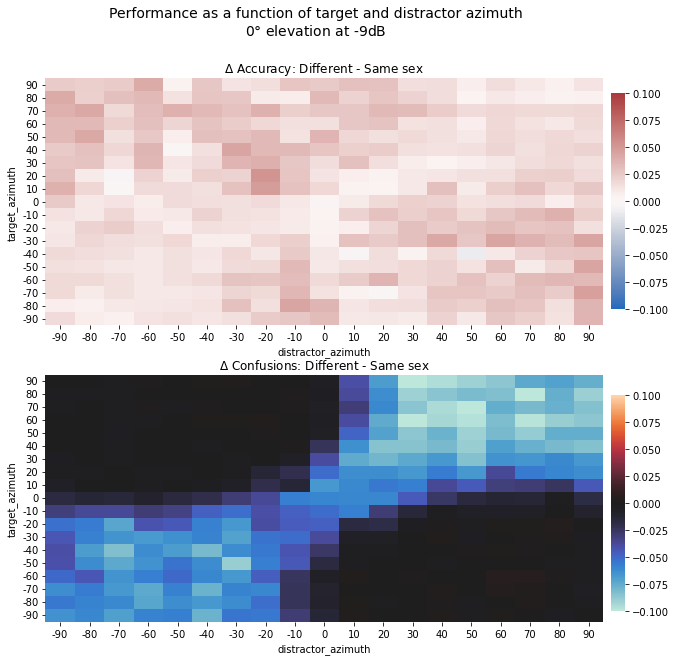

In [47]:
# plot all plots so far onto one figure
# cols = ['Total', 'Same Sex', 'Different Sex']
# rows = ['Accuracy', 'Confusions']

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=False, sharey=True)

cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])

same_sex = min_9_db[(min_9_db['condition'] == 'm_m') | (min_9_db['condition'] == 'f_f')]
diff_sex = min_9_db[(min_9_db['condition'] == 'm_f') | (min_9_db['condition'] == 'f_m')]

diff = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean() - same_sex.groupby(["target_azimuth", "distractor_azimuth"])['accuracy'].mean()
sns.heatmap(diff.unstack(), vmin=-0.1, vmax=0.1, cmap='vlag', cbar=True, cbar_ax=cbar_ax_1, ax=axs[0])
diff = diff_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean() - same_sex.groupby(["target_azimuth", "distractor_azimuth"])['confusions'].mean()
sns.heatmap(diff.unstack(), vmin=-0.1, vmax=0.1, cmap='icefire', cbar=True, cbar_ax=cbar_ax_2, ax=axs[1])

# for ax, col in zip(axs[0], cols):
axs[0].set_title("$\Delta$ Accuracy: Different - Same sex ", )#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("$\Delta$ Confusions: Different - Same sex") # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# fig.tight_layout(rect=[0,0,.9,1])
plt.suptitle('Performance as a function of target and distractor azimuth\n$0\degree$ elevation at -9dB', fontsize=14, y=0.98);

np.vectorize(lambda ax: ax.invert_yaxis())(axs);

In [36]:
import pickle 

with open("/om2/user/imgriff/projects/Auditory-Attention/train_models_08_02.pkl", "rb") as f:
    models = pickle.load(f)

In [37]:
models

['/om2/user/rphess/Auditory-Attention/config/binaural_attn/word_task_mixed_cue_large_architecture.yml',
 '/om2/user/rphess/Auditory-Attention/config/binaural_attn/word_task_voice_cue_large_architecture.yml']